In [1]:
import torch
import argparse
import tinycudann as tcnn
from manage_objs import *
from sdf.utils2 import *
from hash_imports.encodings import HashEncoding

def save_mesh(models, mode,no_of_rots,W=None,N=None,M=None,save_path='inferences/', resolution=256):
        for j, model in enumerate(models):
            if N == None and M == None and W==None:
                save_path1 = save_path+f'{j}.obj'
            elif mode == 'lora': 
                save_path1 = save_path+f'N_M_{j}.obj'
            elif mode == 'normal': 
                save_path1 = save_path+f'W_{j}.obj'
            print(f"==> Saving mesh to {save_path1}")
            if no_of_rots == 1:
                os.makedirs(os.path.dirname(save_path1), exist_ok=True)

                def query_func(pts,model):
                    pts = pts.to('cuda')
                    with torch.no_grad():   
                        with torch.cuda.amp.autocast(enabled=True):
                            # model.encoder.params = torch.nn.Parameter(model.encoder.params*w.params)
                            sdfs = model(pts,mode,W,N,M) #TODO
                    return sdfs

                bounds_min = torch.FloatTensor([-1, -1, -1])
                bounds_max = torch.FloatTensor([1, 1, 1])
                
                vertices, triangles = extract_geometry(bounds_min, bounds_max, resolution=resolution, threshold=0, query_func=query_func, model=model)
                mesh = trimesh.Trimesh(vertices, triangles, process=False)
                mesh.export(save_path1)
            # vertices, triangles = extract_geometry(bounds_min, bounds_max, resolution=resolution, threshold=0, query_func=query_func)
                print(f"==> Finished saving mesh {j+1}/{len(models)}.")
            # mesh = trimesh.Trimesh(vertices, triangles, process=False) # important, process=True leads to seg fault...
            # mesh.export(save_path)
            else:
                w =W
                
                for i in range(no_of_rots):
                    save_path2 = save_path +f'obj_{j}_rot_{i}.obj'
                    os.makedirs(os.path.dirname(save_path2), exist_ok=True)

                    def query_func(pts,model):
                        pts = pts.to('cuda')
                        with torch.no_grad():   
                            with torch.cuda.amp.autocast(enabled=True):
                                # model.encoder.params = torch.nn.Parameter(model.encoder.params*w.params)
                                sdfs = model(pts,mode,w,N,M) #TODO
                        return sdfs

                    bounds_min = torch.FloatTensor([-1, -1, -1])
                    bounds_max = torch.FloatTensor([1, 1, 1])
                    
                    vertices, triangles = extract_geometry(bounds_min, bounds_max, resolution=resolution, threshold=0, query_func=query_func, model=model)
                    mesh = trimesh.Trimesh(vertices, triangles, process=False)
                    mesh.export(save_path2)
                    w = torch.matmul(w,W)
                    print(f"==> Finished saving mesh {j}/{len(models)}.")
                    

        print(f"==> Finished saving meshes.")





In [2]:


mode = 'normal'
W = None
N = None
M = None 
B1 = None 
B2 = None
no_of_rots = 1
workspace1 = f'hash_workspace_obj12_2_3_10/'
# workspace1 = f'test/'

_n = 40
from sdf.network_tcnn import SDFNetwork            
tcnn_network = tcnn.Network(
                                    n_input_dims=32,
                                    n_output_dims=1,
                                    network_config={
                                        "otype": "FullyFusedMLP",
                                        "activation": "ReLU",
                                        "output_activation": "None",
                                        "n_neurons": 64,
                                        "n_hidden_layers": 2,
                                    },
                                )


# mlp_state_dict = torch.load('saved_models/mlp.pth')
# tcnn_network.load_state_dict(mlp_state_dict)
# tcnn_network = torch.load(workspace1+'GT_mlp_7_8_12.pth')
models = []
for idx in range(_n):
    model = SDFNetwork( tcnn_network, encoding="hashgrid")
    model.encoder = torch.load(workspace1+ f'GT_enc_{idx}.pth')
    model.backbone = torch.load(workspace1+"GT_mlp.pth")
    models.append(model)

W= torch.load(workspace1+'W.pth')


    


In [3]:
W.shape

torch.Size([16384, 16384])

In [4]:
models[0].encoder.hash_table.shape


torch.Size([16384, 2])

In [5]:
decoder1 = torch.load('test/GT_mlp.pth')
decoder2 = torch.load('hash_workspace_obj12_2_3_10/GT_mlp.pth')

In [6]:
decoder1.params


Parameter containing:
tensor([-2.1359e-01, -4.8546e-02, -2.2082e-01,  ..., -5.1055e-06,
         5.1913e-06,  5.1849e-07], device='cuda:0', requires_grad=True)

In [7]:
decoder2.params

Parameter containing:
tensor([-2.1359e-01, -4.8546e-02, -2.2082e-01,  ..., -5.1055e-06,
         5.1913e-06,  5.1849e-07], device='cuda:0', requires_grad=True)

In [8]:
encoder1 = torch.load('test/GT_enc_0.pth')
encoder2 = torch.load('hash_workspace_obj12_2_3_10/GT_enc_0.pth')

In [9]:
encoder1.hash_table


Parameter containing:
tensor([[ 8.9059e-05,  8.4782e-04],
        [ 1.8758e-02,  2.4491e-03],
        [-1.1035e-03,  2.3129e-03],
        ...,
        [ 5.9666e-03,  6.5348e-03],
        [ 5.7484e-03,  6.6350e-03],
        [ 5.8801e-03,  6.5196e-03]], device='cuda:0', requires_grad=True)

In [10]:
encoder2.hash_table


Parameter containing:
tensor([[0.0413, 0.0271],
        [0.0409, 0.0272],
        [0.0007, 0.0141],
        ...,
        [0.0094, 0.0048],
        [0.0095, 0.0047],
        [0.0096, 0.0047]], device='cuda:0', requires_grad=True)

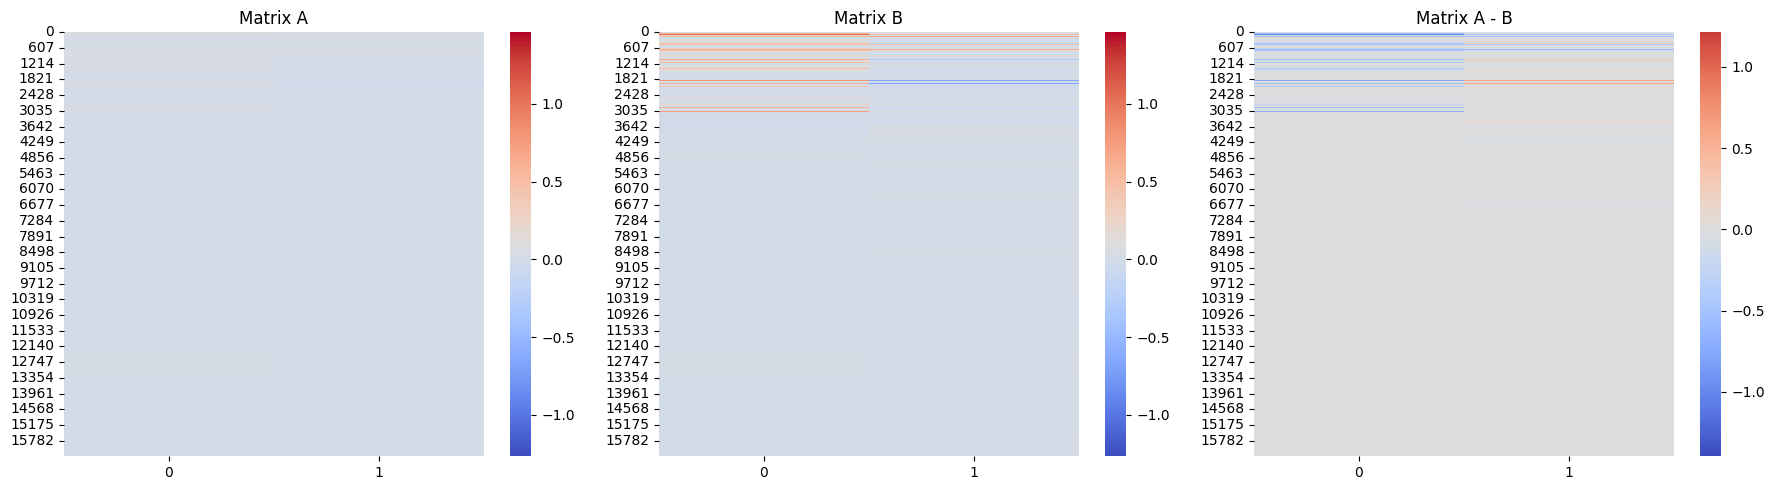

In [11]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

def generate_matrices(N=16000):
    np.random.seed(42)
    A = np.random.rand(N, 2)  # Random values between 0 and 1
    B = np.random.rand(N, 2)  # Another set of random values
    return A, B

def plot_heatmaps(A, B, cmap="coolwarm"):
    vmin = min(A.min(), B.min())
    vmax = max(A.max(), B.max())
    
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    
    sns.heatmap(A, ax=axes[0], cmap=cmap, cbar=True, vmin=vmin, vmax=vmax)
    axes[0].set_title("Matrix A")
    
    sns.heatmap(B, ax=axes[1], cmap=cmap, cbar=True, vmin=vmin, vmax=vmax)
    axes[1].set_title("Matrix B")
    
    diff = A - B
    sns.heatmap(diff, ax=axes[2], cmap=cmap, center=0, cbar=True)
    axes[2].set_title("Matrix A - B")
    
    plt.tight_layout()
    plt.show()

if __name__ == "__main__":
    N = 16384
    A = encoder1.hash_table.detach().to('cpu')
    B = encoder2.hash_table.detach().to('cpu')
    plot_heatmaps(A, B)


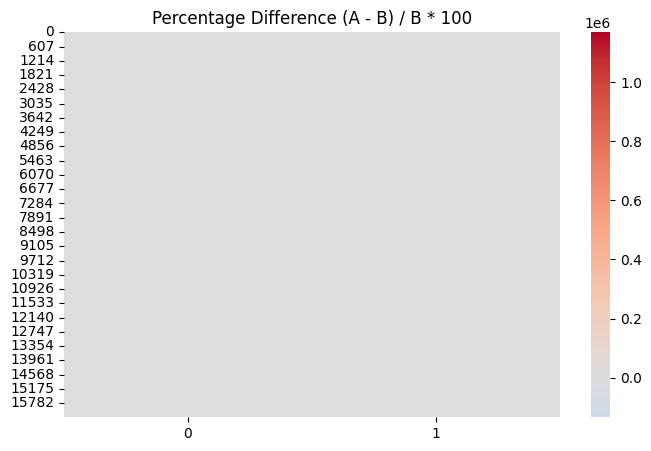

In [12]:
def plot_difference(A, B, cmap="coolwarm"):
    diff_percentage = ((A - B) / (B + 1e-8)) * 100  # Avoid division by zero
    plt.figure(figsize=(8, 5))
    sns.heatmap(diff_percentage, cmap=cmap, center=0, cbar=True)
    plt.title("Percentage Difference (A - B) / B * 100")
    plt.show()
plot_difference(A, B)